This notebook builds a small LangGraph-based mathematical planning agent that can interpret a multi-step arithmetic request, decide the next action, execute it with a tool, and continue until the task is complete.

What the notebook does

- It defines a set of arithmetic tools:
    - add
    - multiply
    - subtract
    - divide
    - power
- It initializes a Groq-backed LLM using ChatGroq.
- It uses structured output from the LLM to decide the next action in a workflow.
- It creates a stateful graph with:
    - planner node
    - tool executor node
    - final node
- The planner decides which operation should happen next based on:
    - the original question
    - completed history
    - last result
    - required operation order
- The executor runs the selected tool on the appropriate arguments and stores the result in state.
- The graph loops until the planner selects finish, then the final node returns the final numerical answer.

Key design

1. Tool registry
     The notebook wraps arithmetic functions as LangChain tools and stores them in TOOL_REGISTRY. Each tool is designed to be called by name and invoked with arguments.

2. Structured action model
     The NextAction Pydantic model defines the planner output schema. It contains:
     - action: which operation to perform next or finish
     - x and y: numeric inputs for the tool
     - reason: why the action was chosen
     - final_answer: optional final result when finished

3. Agent state
     AgentState is a TypedDict that tracks:
     - question
     - action
     - x
     - y
     - reason
     - last_result
     - final_answer
     - history
     - steps

4. Planner node
     planner_node builds a prompt that instructs the LLM to act as a mathematical workflow planner. It:
     - reads the user request
     - checks prior operations
     - uses the last result when needed
     - never performs arithmetic itself
     - returns exactly one next action

5. Router
     planner_router decides whether execution continues or the process ends:
     - if action == "finish" -> route to final
     - otherwise -> route to tool_executor

6. Tool executor
     tool_executor_node looks up the chosen tool in TOOL_REGISTRY, prepares arguments, calls the tool, and appends the operation result to history. It also tracks the step count.

7. Final node
     final_node extracts the final answer from the state and emits it.

8. Workflow graph
     The notebook compiles a StateGraph:
     - START -> planner
     - planner -> execute or finish
     - tool_executor -> planner
     - final -> END

What it demonstrates

This notebook is a practical example of:
- tool-using LLMs
- structured output parsing
- stateful agent workflows
- LangGraph orchestration
- reasoning over sequential multi-step tasks

Example execution

The notebook runs a question asking to:
- Add 10 and 20
- Multiply the result by 3
- Subtract 15
- Divide by 5
- Raise to the power of 2

The workflow correctly processes each step and returns the final result as 225.0.

Technologies used

- Python
- LangChain
- LangGraph
- Groq API / ChatGroq
- Pydantic
- Python typing utilities
- dotenv for environment variables

Overall purpose

The notebook is an educational and functional prototype of a reasoning agent that performs chained mathematical computations by planning each step with an LLM and executing them with deterministic tools. It shows how an LLM can be used not just for direct answers, but for orchestrating a controlled sequence of tool calls in a stateful graph.

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
from dotenv import load_dotenv
import os

from typing import Literal
from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.tools import tool

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

In [8]:
load_dotenv()  # Load environment variables from .env file

True

##### Create tools

In [10]:
@tool
def add(a: float, b: float) -> float:
    """Add two numbers."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers."""
    return a * b

@tool
def subtract(a: float, b: float) -> float:
    """Subtract b from a."""
    return a - b

@tool
def divide(a: float, b: float) -> float:
    """Divide a by b."""

    if b == 0:
        raise ValueError(
            "Division by zero is not allowed."
        )

    return a / b

@tool
def power(
    base: float,
    exponent: float
) -> float:
    """Raise base to exponent."""

    return base ** exponent

In [32]:
TOOL_REGISTRY = {
    "add": add,

    "multiply": multiply,

    "subtract": subtract,

    "divide": divide,

    "power": power,
}

##### Initializing LLM

In [14]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0.0)
    
llm.invoke("hi there")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to "hi there". It\'s a greeting. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 73, 'total_tokens': 110, 'completion_time': 0.038102153, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.004156844, 'prompt_tokens_details': None, 'queue_time': 0.15710003, 'total_time': 0.042258997}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e23fc997ca', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a065b1-dd1b-7531-a704-37e50c7be380-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 37, 'total_tokens': 110, 'output_token_details': {'reasoning': 19}})

##### Pydantic for LLM structured decision

In [15]:
class NextAction(BaseModel):
    action: Literal["add","multiply","subtract","divide","power","finish"] = Field(description=("The next operation that must be executed."))

    x: float | None = Field(default=None,description=("First argument For power this is the base."))

    y: float | None = Field(default=None,description=("Second argument For power this is the exponent."))

    reason: str = Field(description=("Brief reason for choosing this action."))

    final_answer: float | None = Field(default=None, description=("Final numerical answer when action is finish."))


##### Defining State

In [17]:
class AgentState(TypedDict, total=False):

    question: str

    action: str

    x: float

    y: float

    reason: str

    last_result: float

    final_answer: float

    history: list[dict]

    steps: int

##### Planner node

In [21]:
planner_llm = llm.with_structured_output(NextAction)

def planner_node(state: AgentState):

    history = state.get("history", [])

    history_text = ""

    for index, item in enumerate(
        history,
        start=1
    ):
        history_text += (
            f"\nStep {index}: "
            f"{item['tool']} "
            f"with arguments "
            f"{item['args']} "
            f"returned "
            f"{item['result']}"
        )
    prompt = f"""

        You are a mathematical workflow planner.

        Your job is ONLY to decide the NEXT operation.

        Available operations:

        add
        multiply
        subtract
        divide
        power
        finish


        Original user request:

        {state["question"]}


        Already completed operations:

        {history_text if history_text else "None"}


        Last result:

        {state.get("last_result", "None")}


        Rules:

        1. Follow the user's requested operation order exactly.

        2. Execute only ONE operation at a time.

        3. If an operation depends on the previous result,
        use the last result as x.

        4. For add:
        x = first number
        y = second number

        5. For multiply:
        x = first number
        y = second number

        6. For subtract:
        result = x - y

        7. For divide:
        result = x / y

        8. For power:
        x = base
        y = exponent

        9. Never perform calculations yourself.

        10. When every requested operation has been executed,
            return action="finish".

        """

    decision = planner_llm.invoke(prompt)

    print("\n" + "=" * 60)

    print("PLANNER DECISION")

    print("=" * 60)

    print("Action:", decision.action)

    print("x:", decision.x)

    print("y:", decision.y)

    print("Reason:", decision.reason)

    result = {
        "action":
            decision.action,
        "reason":
            decision.reason,
    }

    if decision.x is not None:
        result["x"] = decision.x

    if decision.y is not None:
        result["y"] = decision.y

    if decision.final_answer is not None:
        result["final_answer"] = (decision.final_answer)

    return result

##### Define Router

In [22]:
def planner_router(state: AgentState) -> Literal["execute", "finish"]:

    if state["action"] == "finish":

        return "finish"

    return "execute"

##### Tool Executor

In [23]:
def tool_executor_node(state: AgentState):

    action = state["action"]

    x = state["x"]

    y = state["y"]

    selected_tool = TOOL_REGISTRY[action]

    print("\nSelected from TOOL_REGISTRY:")

    print(selected_tool.name)

    if action == "power":
        arguments = {
            "base": x,
            "exponent": y
        }

    else:
        arguments = {
            "a": x,
            "b": y,
        }

    result = selected_tool.invoke(arguments)

    print("Arguments:", arguments)

    print("Tool Result:", result)

    history = state.get("history", []).copy()

    history.append({
        "tool": action,
        "args": arguments,
        "result": result,
    })

    return {
        "last_result":float(result),
        "history": history,
        "steps": state.get( "steps", 0) + 1
    }

##### Final node

In [24]:
def final_node(state: AgentState):

    final_answer = state.get("last_result")

    print("\n" + "=" * 60)

    print( "FINAL ANSWER:", final_answer)

    print("=" * 60)

    return {
        "final_answer": final_answer
    }

##### Create Graph

In [25]:
workflow = StateGraph(AgentState)

workflow.add_node("planner",planner_node)

workflow.add_node("tool_executor",tool_executor_node)

workflow.add_node("final", final_node)

In [26]:
workflow.add_edge(START, "planner")

workflow.add_conditional_edges("planner", planner_router,
    {
        "execute":
            "tool_executor",
        "finish":
            "final",
    }
)

workflow.add_edge("tool_executor", "planner")

workflow.add_edge("final", END)

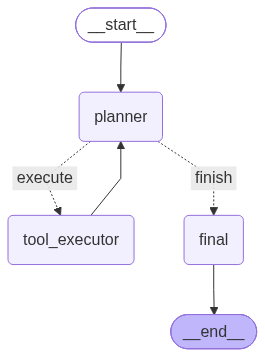

In [28]:
app = workflow.compile()
app

##### Run agent

In [30]:
question = """

Perform these calculations in order:

1. Add 10 and 20.
2. Multiply the result by 3.
3. Subtract 15 from the result.
4. Divide the result by 5.
5. Raise the result to the power of 2.

"""

In [33]:
result = app.invoke(
    {
        "question": question,
        "history": [],
        "steps": 0,
    },
    config={
        "recursion_limit": 20
    }
)


PLANNER DECISION
Action: add
x: 10.0
y: 20.0
Reason: First operation: add 10 and 20

Selected from TOOL_REGISTRY:
add
Arguments: {'a': 10.0, 'b': 20.0}
Tool Result: 30.0

PLANNER DECISION
Action: multiply
x: 30.0
y: 3.0
Reason: Next step is to multiply the last result (30) by 3.

Selected from TOOL_REGISTRY:
multiply
Arguments: {'a': 30.0, 'b': 3.0}
Tool Result: 90.0

PLANNER DECISION
Action: subtract
x: 90.0
y: 15.0
Reason: Next step is to subtract 15 from the last result 90.

Selected from TOOL_REGISTRY:
subtract
Arguments: {'a': 90.0, 'b': 15.0}
Tool Result: 75.0

PLANNER DECISION
Action: divide
x: 75.0
y: 5.0
Reason: Next step is to divide the current result (75.0) by 5 as per the user's request.

Selected from TOOL_REGISTRY:
divide
Arguments: {'a': 75.0, 'b': 5.0}
Tool Result: 15.0

PLANNER DECISION
Action: power
x: 15.0
y: 2.0
Reason: Next step is to raise the last result (15.0) to the power of 2.

Selected from TOOL_REGISTRY:
power
Arguments: {'base': 15.0, 'exponent': 2.0}
Too